In [232]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import seaborn as sns
import h5py
from collections import Counter
import scipy.sparse as sp
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib_venn import venn3
import pyranges as pr
import yaml
import time
from itertools import combinations
import gget

import anndata as an
import scanpy as sc
import rapids_singlecell as rsc

import scvi
from scvi.external import SysVI

import cupy as cp
import cudf
import rmm
from rmm.allocators.cupy import rmm_cupy_allocator

from cuml.manifold.umap import simplicial_set_embedding
from scanpy.tools._utils import get_init_pos_from_paga 
from cuml.manifold.umap import find_ab_params

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Enable `managed_memory`
rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

sc.settings.verbosity = 3

# Load gene resources

In [ ]:
%%time 
# === Load and filter GTF ===
gtf_file = "/nfs/turbo/umms-indikar/shared/projects/reference_genome/prebuilt/refdata-gex-GRCh38-2024-A/genes/genes.gtf"
gtf = pr.read_gtf(gtf_file)

exons = gtf[gtf.Feature == "exon"].df
print(f"{exons.shape=}")
exons.head()


In [95]:
fpath = "../../resources/isoform_map.csv.gz"

idf = pd.read_csv(fpath)
print(f"{idf.shape=}")

idf['uniprot'] = np.where(idf['UniProtKB/TrEMBL ID'].isna(), idf['UniProtKB/Swiss-Prot ID'], idf['UniProtKB/TrEMBL ID'])

transcript_2_uniprot = dict(zip(idf['Transcript name'].values, idf['uniprot'].values))

idf.head()

idf.shape=(110149, 11)


,Gene stable ID,Gene stable ID version,Transcript stable ID,Transcript stable ID version,Protein stable ID,Protein stable ID version,Transcript length (including UTRs and CDS),Transcript name,Gene name,UniProtKB/Swiss-Prot ID,UniProtKB/TrEMBL ID,uniprot
0,ENSG00000198888,ENSG00000198888.2,ENST00000361390,ENST00000361390.2,ENSP00000354687,ENSP00000354687.2,956,MT-ND1-201,MT-ND1,P03886,U5Z754,U5Z754
1,ENSG00000198763,ENSG00000198763.3,ENST00000361453,ENST00000361453.3,ENSP00000355046,ENSP00000355046.4,1042,MT-ND2-201,MT-ND2,P03891,Q7GXY9,Q7GXY9
2,ENSG00000198804,ENSG00000198804.2,ENST00000361624,ENST00000361624.2,ENSP00000354499,ENSP00000354499.2,1542,MT-CO1-201,MT-CO1,P00395,U5YWV7,U5YWV7
3,ENSG00000198712,ENSG00000198712.1,ENST00000361739,ENST00000361739.1,ENSP00000354876,ENSP00000354876.1,684,MT-CO2-201,MT-CO2,P00403,U5Z487,U5Z487
4,ENSG00000228253,ENSG00000228253.1,ENST00000361851,ENST00000361851.1,ENSP00000355265,ENSP00000355265.1,207,MT-ATP8-201,MT-ATP8,P03928,U5YV54,U5YV54


In [3]:
fpath = "../../resources/allTFs_hg38.txt"
tf_list = [x.strip() for x in open(fpath)]
tf_list[:10]

['ZNF354C',
 'KLF12',
 'ZNF143',
 'ZIC2',
 'ZNF274',
 'SP2',
 'ZBTB7A',
 'BCL6B',
 'ZBTB49',
 'ZIC1']

# Load Data

In [4]:
%%time
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/isoforms.h5ad"
adata = sc.read_h5ad(fpath)
adata

CPU times: user 233 ms, sys: 419 ms, total: 652 ms
Wall time: 1.18 s


AnnData object with n_obs × n_vars = 21062 × 113335
    obs: 'dataset', 'dataset_bdata', 'source', 'cluster', 'group', 'label', 'filter_pass', 'bm_clusters', 'subgroup'
    var: 'gene_id', 'gene_name', 'gene_type', 'transcript_name', 'transcript_type', 'Chromosome', 'Start', 'End', 'transcript_id'
    uns: 'subgroup_colors'
    obsm: 'X_umap'

# Preprocessing

In [5]:
rsc.get.anndata_to_GPU(adata)
rsc.pp.filter_genes(adata, min_counts=30)

adata.layers['counts'] = adata.X.copy()

rsc.pp.normalize_total(adata, target_sum=1e4)
rsc.pp.log1p(adata)

adata.layers['log_norm'] = adata.X.copy()
adata

filtered out 43826 genes that are detected in less than 30 counts


AnnData object with n_obs × n_vars = 21062 × 69509
    obs: 'dataset', 'dataset_bdata', 'source', 'cluster', 'group', 'label', 'filter_pass', 'bm_clusters', 'subgroup'
    var: 'gene_id', 'gene_name', 'gene_type', 'transcript_name', 'transcript_type', 'Chromosome', 'Start', 'End', 'transcript_id', 'n_counts', 'n_cells'
    uns: 'subgroup_colors', 'log1p'
    obsm: 'X_umap'
    layers: 'counts', 'log_norm'

# Isoform Table

In [6]:
%%time 
adata.X = adata.layers['counts'].copy()
rsc.get.anndata_to_GPU(adata)
print(f"{type(adata.X)=}")

aggdata = rsc.get.aggregate(
    adata, 
    by='group',
    func='sum',
    axis=0,
)

rsc.get.anndata_to_CPU(aggdata, convert_all=True,)
df = aggdata.to_df(layer='sum')
df = df.T
df['total_transcript'] = df.sum(axis=1)

df = pd.merge(
    df, adata.var[['gene_name', 'gene_type', 'transcript_type']],
    how='left',
    left_index=True,
    right_index=True,
)
df = df.reset_index()
df = df.sort_values(by=['gene_name', 'transcript_name'])
df = df.reset_index(drop=True)
df['is_tf'] = df['gene_name'].isin(tf_list)
df.head()

type(adata.X)=<class 'cupyx.scipy.sparse._csr.csr_matrix'>
CPU times: user 174 ms, sys: 9.52 ms, total: 184 ms
Wall time: 187 ms


,transcript_name,bm_other,intial,reprogram,target,total_transcript,gene_name,gene_type,transcript_type,is_tf
0,A1BG-202,26.0,10.0,36.0,6.0,78.0,A1BG,protein_coding,retained_intron,False
1,A1BG-203,31.0,34.0,104.0,8.0,177.0,A1BG,protein_coding,protein_coding_CDS_not_defined,False
2,A1BG-204,2909.0,8093.0,10093.0,628.0,21723.0,A1BG,protein_coding,retained_intron,False
3,A1BG-AS1-202,154.0,44.0,23.0,41.0,262.0,A1BG-AS1,lncRNA,lncRNA,False
4,A1BG-AS1-203,2.0,22.0,16.0,0.0,40.0,A1BG-AS1,lncRNA,lncRNA,False


# Add metadata

In [7]:
%%time
pdf = df.copy()

# protien-coding isoforms only
# pdf = pdf[pdf['transcript_type'] == 'protein_coding']

# count the number of isoforms per gene
pdf['n_isoforms'] = pdf.groupby('gene_name')['transcript_name'].transform('count')
pdf = pdf[pdf['n_isoforms'] > 1]

# add grouped expression counts
grouped = pdf.groupby('gene_name')[['bm_other', 'intial', 'reprogram', 'target']].sum()
sum_columns  = [f'{col}_sum' for col in grouped.columns]
grouped.columns = sum_columns
pdf = pdf.merge(grouped, on='gene_name', how='left')

pdf['total_gene'] = pdf[sum_columns].sum(axis=1)

# add percentages
for col in ['bm_other', 'intial', 'reprogram', 'target']:
    sum_col = f'{col}_sum'
    pct_col = f'{col}_pct'
    pdf[pct_col] = pdf[col] / pdf[sum_col]

print(pdf[['gene_name', 'transcript_name', 'intial_pct', 'reprogram_pct', 'target_pct']].head().to_string())

  gene_name transcript_name  intial_pct  reprogram_pct  target_pct
0      A1BG        A1BG-202    0.001229       0.003518    0.009346
1      A1BG        A1BG-203    0.004178       0.010163    0.012461
2      A1BG        A1BG-204    0.994593       0.986319    0.978193
3  A1BG-AS1    A1BG-AS1-202    0.156028       0.080702    0.546667
4  A1BG-AS1    A1BG-AS1-203    0.078014       0.056140    0.000000
CPU times: user 29 ms, sys: 1.01 ms, total: 30 ms
Wall time: 29.6 ms


# Dominance

In [8]:
def get_top(df, col):
    # Remove groups with any NaN
    mask = df.groupby('gene_name', observed=True)[col].transform(lambda x: x.isna().any())
    df_valid = df[~mask]

    # Get index of max value per group
    top_idx = df_valid.groupby('gene_name', observed=True)[col].idxmax()
    counts = df_valid.groupby('gene_name', observed=True)[col].apply(lambda x: (x == x.max()).sum())

    # Build mapping and drop ties
    top_map = df_valid.loc[top_idx, ['gene_name', 'transcript_name']].set_index('gene_name')['transcript_name']
    top_map[counts > 1] = np.nan

    return df['gene_name'].map(top_map)

for col in ['intial_pct', 'reprogram_pct', 'target_pct']:
    pdf[f'{col}_top'] = get_top(pdf, col)

pdf.head()

,transcript_name,bm_other,intial,reprogram,target,total_transcript,gene_name,gene_type,transcript_type,is_tf,...,reprogram_sum,target_sum,total_gene,bm_other_pct,intial_pct,reprogram_pct,target_pct,intial_pct_top,reprogram_pct_top,target_pct_top
0,A1BG-202,26.0,10.0,36.0,6.0,78.0,A1BG,protein_coding,retained_intron,False,...,10233.0,642.0,21978.0,0.008766,0.001229,0.003518,0.009346,A1BG-204,A1BG-204,A1BG-204
1,A1BG-203,31.0,34.0,104.0,8.0,177.0,A1BG,protein_coding,protein_coding_CDS_not_defined,False,...,10233.0,642.0,21978.0,0.010452,0.004178,0.010163,0.012461,A1BG-204,A1BG-204,A1BG-204
2,A1BG-204,2909.0,8093.0,10093.0,628.0,21723.0,A1BG,protein_coding,retained_intron,False,...,10233.0,642.0,21978.0,0.980782,0.994593,0.986319,0.978193,A1BG-204,A1BG-204,A1BG-204
3,A1BG-AS1-202,154.0,44.0,23.0,41.0,262.0,A1BG-AS1,lncRNA,lncRNA,False,...,285.0,75.0,958.0,0.487342,0.156028,0.080702,0.546667,A1BG-AS1-204,A1BG-AS1-209,A1BG-AS1-202
4,A1BG-AS1-203,2.0,22.0,16.0,0.0,40.0,A1BG-AS1,lncRNA,lncRNA,False,...,285.0,75.0,958.0,0.006329,0.078014,0.056140,0.000000,A1BG-AS1-204,A1BG-AS1-209,A1BG-AS1-202


In [9]:
qdf = pdf.copy()
print(f"raw {qdf.shape=}")

# Drop rows where all _top values are the same (excluding NaN-only rows)
top_cols = ['intial_pct_top', 'reprogram_pct_top', 'target_pct_top']
mask = qdf[top_cols].nunique(axis=1, dropna=False) == 1
qdf = qdf[~mask]
print(f"filtered {qdf.shape=}")
print(qdf[['gene_name', 'transcript_name', 'intial_pct_top','reprogram_pct_top', 'target_pct_top']].head().to_string())

raw qdf.shape=(60119, 23)
filtered qdf.shape=(34996, 23)
  gene_name transcript_name intial_pct_top reprogram_pct_top target_pct_top
3  A1BG-AS1    A1BG-AS1-202   A1BG-AS1-204      A1BG-AS1-209   A1BG-AS1-202
4  A1BG-AS1    A1BG-AS1-203   A1BG-AS1-204      A1BG-AS1-209   A1BG-AS1-202
5  A1BG-AS1    A1BG-AS1-204   A1BG-AS1-204      A1BG-AS1-209   A1BG-AS1-202
6  A1BG-AS1    A1BG-AS1-206   A1BG-AS1-204      A1BG-AS1-209   A1BG-AS1-202
7  A1BG-AS1    A1BG-AS1-209   A1BG-AS1-204      A1BG-AS1-209   A1BG-AS1-202


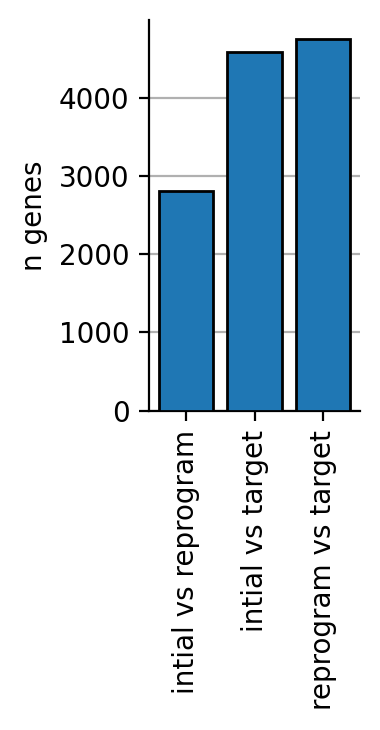

In [10]:
top_cols = ['intial_pct_top', 'reprogram_pct_top', 'target_pct_top']
pairs = list(combinations(top_cols, 2))

# Only one row per gene to avoid duplicate counting
uniq = qdf.drop_duplicates('gene_name')

diff_counts = {}

for a, b in pairs:
    # Count unique gene_names where values differ (and neither is NaN)
    mask = (uniq[a].notna() & uniq[b].notna() & (uniq[a] != uniq[b]))
    key = f"{a.replace('_pct_top','')} vs {b.replace('_pct_top','')}"
    diff_counts[key] = mask.sum()

# Plot
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 2, 3.75
plt.bar(diff_counts.keys(), diff_counts.values(), ec='k', zorder=10)
plt.ylabel("n genes")  # with differing dominant transcripts
plt.grid(axis='y')
plt.xticks(rotation=90)
plt.tight_layout()
sns.despine()
plt.show()

   intial_pct_top reprogram_pct_top target_pct_top
3    A1BG-AS1-204      A1BG-AS1-209   A1BG-AS1-202
8         A2M-201           A2M-201        A2M-208
10    A2M-AS1-203       A2M-AS1-201    A2M-AS1-201
13            NaN         A2ML1-203      A2ML1-201
15     A4GALT-207        A4GALT-207            NaN


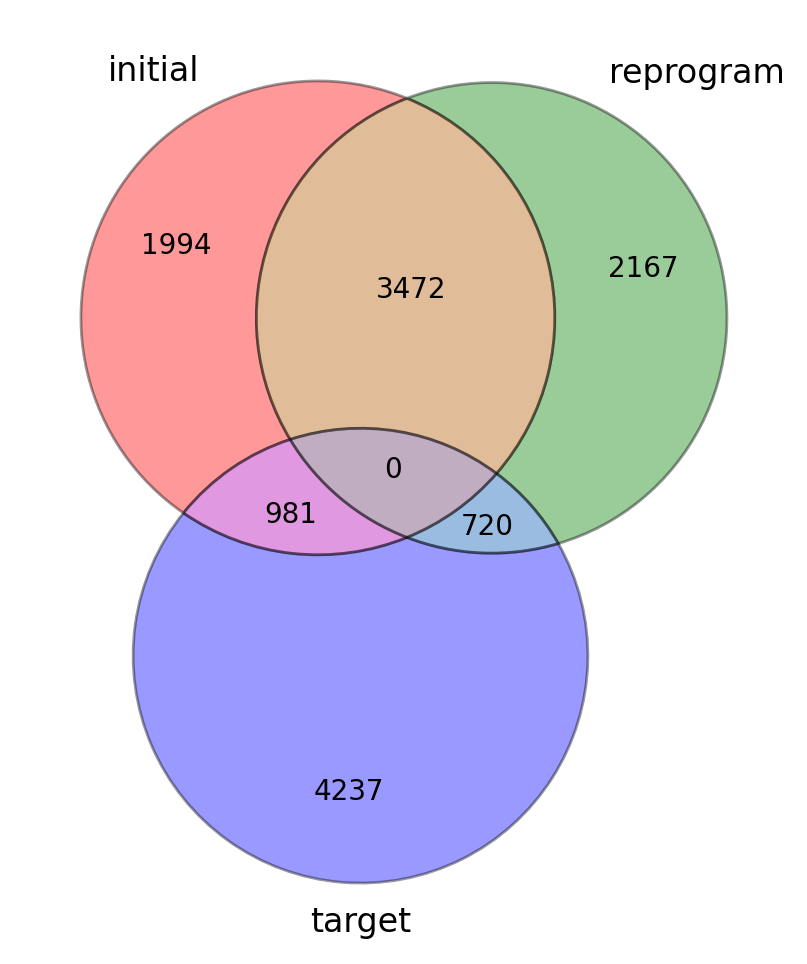

In [11]:
# Drop duplicate gene names to avoid double counting
uniq = qdf.drop_duplicates('gene_name')
print(uniq[['intial_pct_top', 'reprogram_pct_top', 'target_pct_top']].head().to_string())

# Drop NaNs
uniq_clean = uniq.dropna(subset=['intial_pct_top', 'reprogram_pct_top', 'target_pct_top'])

# Convert each column to a set
set1 = set(uniq['intial_pct_top'].dropna())
set2 = set(uniq['reprogram_pct_top'].dropna())
set3 = set(uniq['target_pct_top'].dropna())

# Plot the Venn diagram
plt.figure(figsize=(6, 6))
v = venn3([set1, set2, set3], set_labels=('initial', 'reprogram', 'target'))

# Add edge colors to the Venn patches
for patch in v.patches:
    if patch:  # some regions may be None if they have no area
        patch.set_edgecolor('black')
        patch.set_linewidth(1)

plt.show()

     intial_pct_top reprogram_pct_top target_pct_top
347        ABL1-201          ABL1-202       ABL1-202
945      ADARB1-208        ADARB1-202            NaN
1185       AFF4-201          AFF4-201       AFF4-203
1369       AHRR-211          AHRR-201            NaN
2399     ANXA11-203        ANXA11-203     ANXA11-207
uniq_clean.shape=(564, 23)


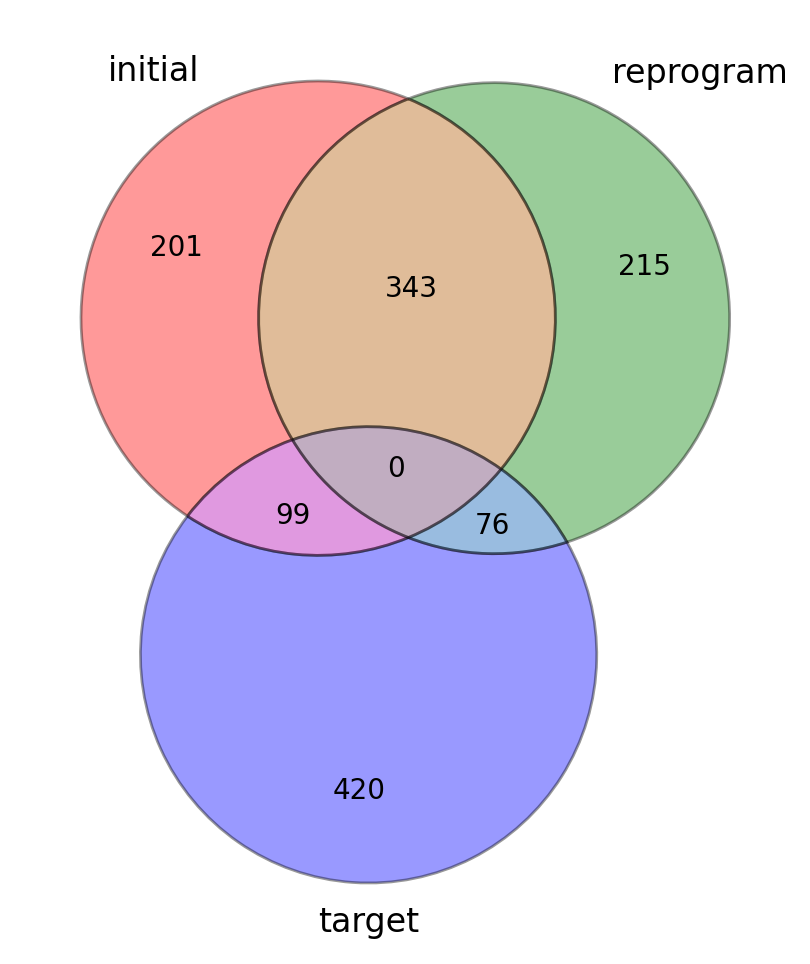

In [12]:
# Drop duplicate gene names to avoid double counting
uniq = qdf.drop_duplicates('gene_name')
uniq = uniq[uniq['is_tf']]
print(uniq[['intial_pct_top', 'reprogram_pct_top', 'target_pct_top']].head().to_string())

# Drop NaNs
uniq_clean = uniq.dropna(subset=['intial_pct_top', 'reprogram_pct_top', 'target_pct_top'])
print(f"{uniq_clean.shape=}")

# Convert each column to a set
set1 = set(uniq['intial_pct_top'].dropna())
set2 = set(uniq['reprogram_pct_top'].dropna())
set3 = set(uniq['target_pct_top'].dropna())

# Plot the Venn diagram
plt.figure(figsize=(6, 6))
v = venn3([set1, set2, set3], set_labels=('initial', 'reprogram', 'target'))

# Add edge colors to the Venn patches
for patch in v.patches:
    if patch:  # some regions may be None if they have no area
        patch.set_edgecolor('black')
        patch.set_linewidth(1)

plt.show()

In [17]:
"""
Top genes by expression with different dominant isoforms
"""

plot_df = pdf.copy()

plot_df = plot_df[~plot_df['gene_name'].str.startswith("MT")]
plot_df = plot_df[~plot_df['gene_name'].str.startswith("RP")]

# Drop rows where all _top values are the same (excluding NaN-only rows)
top_cols = ['intial_pct_top', 'reprogram_pct_top', 'target_pct_top']
mask = plot_df[top_cols].nunique(axis=1, dropna=False) == 1
plot_df = plot_df[~mask]
plot_df = plot_df.sort_values(by='total_gene', ascending=False)

plot_df[['gene_name', 'transcript_name', 'intial_sum', 'reprogram_sum',
       'target_sum', 'intial_pct_top', 'reprogram_pct_top',
       'target_pct_top']].head(5)

top_genes = plot_df['gene_name'].unique().to_list()
print(top_genes[:50])

alpha = 0.01
edf = gget.enrichr(top_genes[:100], database='ontology')
edf = edf[edf['adj_p_val'] < alpha]
print(f"{edf.shape=}")

edf['genes'] = edf['overlapping_genes'].apply(lambda x: ",".join(x))
print(edf[['path_name','genes']].to_string(index=False))


10:46:18 - INFO - Performing Enrichr analysis using database GO_Biological_Process_2021. 
        Please note that there might be a more appropriate database for your application. 
        Go to https://maayanlab.cloud/Enrichr/#libraries for a full list of supported databases.
        


['S100A6', 'MYL6', 'RACK1', 'COL1A2', 'CD63', 'SEC61G', 'VIM', 'PFDN5', 'HSPB1', 'COX7A2', 'NACA', 'COX6C', 'GAS5', 'CD74', 'NUPR1', 'ENSG00000291105', 'SNRPD2', 'CALD1', 'CYTOR', 'DCN', 'TNFRSF11B', 'IGLL1', 'CUTA', 'S100A13', 'PARK7', 'SERPINE2', 'MRPL33', 'TPM1', 'SSBP1', 'LY6E', 'EIF3E', 'HLA-A', 'AIF1', 'RBIS', 'HLA-DRA', 'MRPS24', 'DUT', 'PRSS23', 'ITGB1', 'NAA38', 'NAP1L1', 'ALDOA', 'DKK1', 'HNRNPA1', 'COX5A', 'EIF1', 'CRABP2', 'LUM', 'IGFL2-AS1', 'HLA-DRB1']
edf.shape=(3, 8)
                                                path_name                                                                         genes
negative regulation of programmed cell death (GO:0043069)             GREM1,CD74,HSPA5,UBC,HSPB1,NAA38,NUPR1,PARK7,AZU1,DKK1,YWHAZ,HYPK
    negative regulation of apoptotic process (GO:0043066)       ITGB1,CD74,HSPA5,HSPB1,PARK7,AZU1,DKK1,YWHAZ,HYPK,GREM1,UBC,NAA38,NUPR1
             regulation of apoptotic process (GO:0042981) ITGB1,CD74,HSPA5,HSPB1,PARK7,AZU1,DKK1,YWHAZ,H

In [14]:
"""
Top genes by expression with different dominant isoform in reprogram
"""
is_tf = False

plot_df = pdf.copy()

plot_df = plot_df[~plot_df['gene_name'].str.startswith("MT")]
plot_df = plot_df[~plot_df['gene_name'].str.startswith("RP")]
if is_tf:
    plot_df = plot_df[plot_df['is_tf']]

mask = (plot_df['reprogram_pct_top'] != plot_df['intial_pct_top']) & (plot_df['reprogram_pct_top'] != plot_df['target_pct_top'])
plot_df = plot_df[mask]
plot_df = plot_df.sort_values(by='total_gene', ascending=False)

top_genes = plot_df['gene_name'].unique().to_list()
print(top_genes[:50])

alpha = 0.05
edf = gget.enrichr(top_genes[:50], database='ontology')
edf = edf[edf['adj_p_val'] < alpha]
print(f"{edf.shape=}")

edf['genes'] = edf['overlapping_genes'].apply(lambda x: ",".join(x))
print(edf[['path_name','genes']].to_string(index=False))

10:45:44 - INFO - Performing Enrichr analysis using database GO_Biological_Process_2021. 
        Please note that there might be a more appropriate database for your application. 
        Go to https://maayanlab.cloud/Enrichr/#libraries for a full list of supported databases.
        


['RACK1', 'PFDN5', 'HSPB1', 'GAS5', 'CD74', 'CALD1', 'IGLL1', 'CUTA', 'S100A13', 'SSBP1', 'AIF1', 'HLA-DRA', 'NAA38', 'NAP1L1', 'ALDOA', 'HNRNPA1', 'HLA-DRB1', 'RRBP1', 'VAMP8', 'GMFG', 'PRSS57', 'YWHAZ', 'FAM30A', 'ELANE', 'UCHL1', 'TCEAL3', 'ARL6IP4', 'ATP5F1C', 'HP1BP3', 'HSPA5', 'FAM177A1', 'CNBP', 'IKBIP', 'MRPL36', 'PSMB8', 'MACROH2A1', 'ELOC', 'SERBP1', 'HLA-DPA1', 'PABPC1', 'EID1', 'HNRNPM', 'CAST', 'GLS', 'UQCRQ', 'PCBP2', 'COL6A3', 'RUNX1', 'ACP1', 'SEPTIN6']
edf.shape=(58, 8)
                                                                                                    path_name                                                   genes
                                   regulation of CD4-positive, alpha-beta T cell differentiation (GO:0043370)                                  HLA-DRA,HLA-DRB1,RUNX1
                                                            regulation of mRNA catabolic process (GO:0061013)                         SERBP1,HSPB1,PABPC1,YWHAZ,PSMB8
          

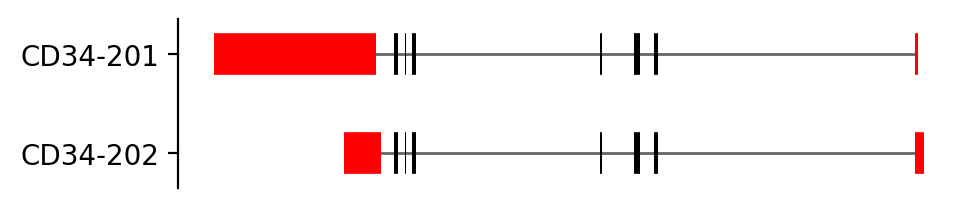

In [268]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_transcript_models(
        exons_df,
        transcript_ids,
        show_coords: bool = False,
        ax: plt.Axes | None = None,
):
    """
    Draw a schematic exon map for the supplied transcripts.

    Parameters
    ----------
    exons_df : pd.DataFrame
        Must have at least 'Start', 'End', 'transcript_name'.
    transcript_ids : list[str]
        Transcript names to plot, top → bottom.
    show_coords : bool, default False
        Whether to display genomic coordinates on the x-axis.
    ax : matplotlib.axes.Axes | None, default None
        Axis to draw on.  If None, a new figure/axis is created.

    Returns
    -------
    matplotlib.axes.Axes
        The axis the plot was drawn on.
    """
    # ── subset ──────────────────────────────────────────────────────────────────
    sel = exons_df[exons_df.transcript_name.isin(transcript_ids)]

    # count exon reuse
    coord_counts = sel.groupby(["Start", "End"]).size().to_dict()

    # ── figure / axis setup ─────────────────────────────────────────────────────
    new_fig = ax is None
    if new_fig:
        fig, ax = plt.subplots(figsize=(5, len(transcript_ids) * 0.6), dpi=200)
    else:
        fig = ax.figure

    # ── main loop ───────────────────────────────────────────────────────────────
    span_pad = 100
    for i, tx in enumerate(transcript_ids):
        tx_exons = sel[sel.transcript_name == tx]
        if tx_exons.empty:
            continue

        start, end = tx_exons.Start.min(), tx_exons.End.max()
        ax.plot([start + span_pad, end - span_pad], [i, i], lw=1,
                color="k", alpha=0.6, zorder=0)

        for row in tx_exons.itertuples():
            color = "red" if coord_counts[(row.Start, row.End)] == 1 else "k"
            ax.plot([row.Start, row.End], [i, i], lw=15, color=color,
                    solid_capstyle="butt", zorder=2)

    # ── axis cosmetics ──────────────────────────────────────────────────────────
    ax.set_yticks(range(len(transcript_ids)))
    ax.set_yticklabels(transcript_ids)
    ax.invert_yaxis()

    if not show_coords:
        ax.tick_params(axis="x", which="both", bottom=False, labelbottom=False)
        ax.set_xlabel("")
        sns.despine(ax=ax, bottom=True)
    else:
        ax.set_xlabel("coordinate")
        sns.despine(ax=ax)

    fig.tight_layout()
    if new_fig:
        plt.margins(y=0.35)
        plt.show()

    return ax

ax = plot_transcript_models(exons_df=exons,
                            transcript_ids=['CD34-201', 'CD34-202'])


In [275]:
def plot_gene_heatmap(gene, plot_df, transcript_2_uniprot, ax=None):
    """
    Plot a heatmap of transcript-level expression for a given gene,
    with a right-side axis showing UniProt IDs.

    Parameters
    ----------
    gene : str
        Gene name to plot.
    plot_df : pd.DataFrame
        Must include:
        'gene_name', 'transcript_name', 'total_transcript',
        'bm_other_pct', 'intial_pct', 'reprogram_pct', 'target_pct'.
    transcript_2_uniprot : dict
        Mapping from transcript name to UniProt ID.
    ax : matplotlib.axes.Axes, optional
        Axis to plot on. If None, creates a new figure.
    
    Returns
    -------
    ax : matplotlib.axes.Axes
        The axis the plot was drawn on.
    """

    # Filter and display transcripts
    tmp = plot_df[plot_df['gene_name'] == gene]
    print(tmp[['transcript_name', 'total_transcript']].drop_duplicates().to_string(index=False))

    # Prepare heatmap matrix
    tmp = tmp.set_index('transcript_name')
    tmp = tmp[['bm_other_pct', 'intial_pct', 'reprogram_pct', 'target_pct']]
    tmp.columns = [x.replace("_pct", "") for x in tmp.columns]
    print(f"{tmp.shape}")

    # Figure and axis
    new_fig = ax is None
    if new_fig:
        plt.rcParams['figure.dpi'] = 200
        plt.rcParams['figure.figsize'] = max(5.5, len(tmp) / 1.2), max(3.5, len(tmp) / 1.2)
        fig, ax = plt.subplots()

    # Plot heatmap
    sns.heatmap(
        tmp,
        square=True,
        cmap='viridis',
        lw=0.5,
        linecolor='w',
        annot=True,
        fmt=".2f",
        cbar=False,
        ax=ax,
    )
    ax.set_title(gene)
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=90)
    ax.tick_params(axis='y', rotation=0)

    # Right y-axis with UniProt IDs
    ax_right = ax.inset_axes([1.0, 0, 0.0001, 1.0])
    ax_right.set_yticks(np.arange(len(tmp)) + 0.5)
    ax_right.set_yticklabels([
        str(transcript_2_uniprot.get(x, "")).replace("nan", "")
        for x in tmp.index
    ])
    ax_right.set_xticks([])
    ax_right.set_ylim(ax.get_ylim())
    ax_right.tick_params(axis='y', length=0)
    ax_right.yaxis.set_label_position("right")
    ax_right.yaxis.tick_right()
    for spine in ax_right.spines.values():
        spine.set_visible(False)

    if new_fig:
        plt.tight_layout()
        plt.show()

    return ax

========== EIF5B ==========
tmp.shape=(3, 23)
transcript_name  total_transcript
      EIF5B-201            1000.0
      EIF5B-202             162.0
      EIF5B-205             618.0
(3, 4)


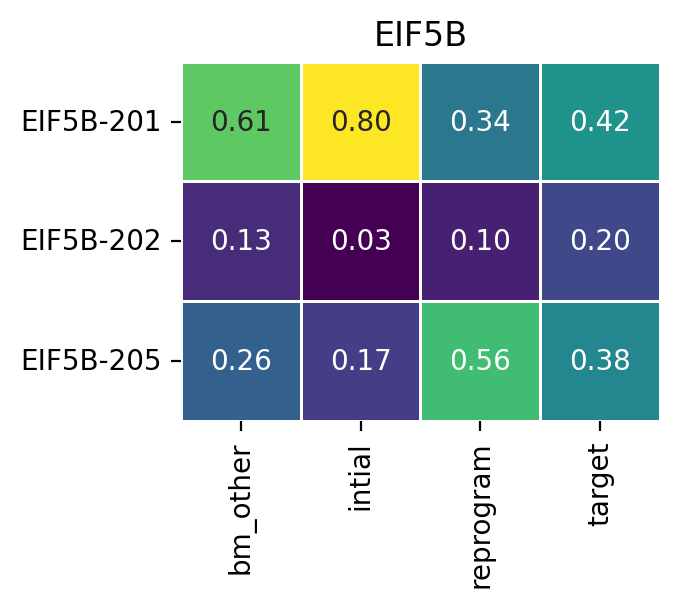

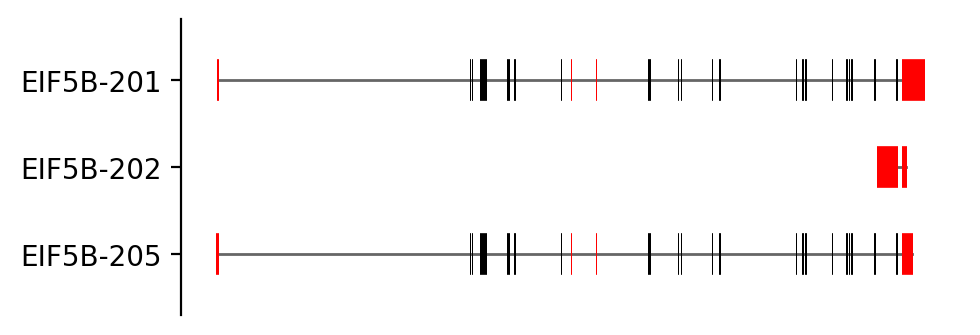

========== ARHGAP10 ==========
tmp.shape=(3, 23)
transcript_name  total_transcript
   ARHGAP10-201            2490.0
   ARHGAP10-204              53.0
   ARHGAP10-206            1070.0
(3, 4)


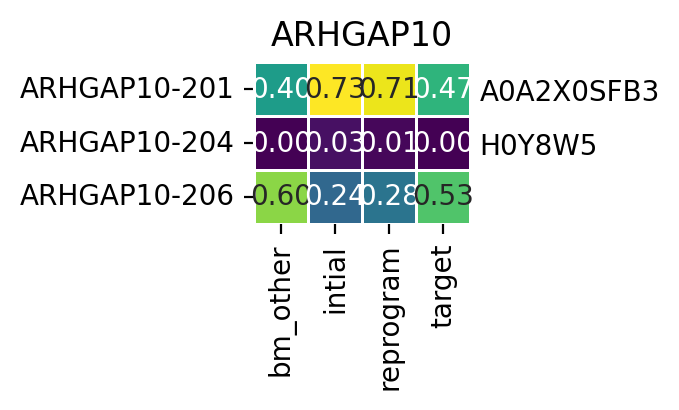

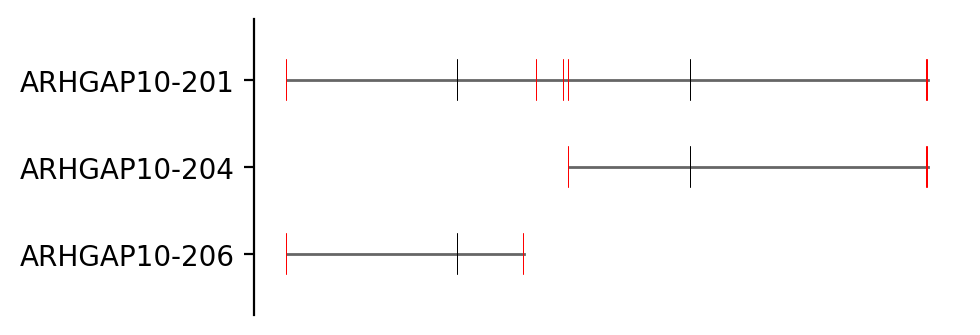

========== ST6GALNAC6 ==========
tmp.shape=(3, 23)
transcript_name  total_transcript
 ST6GALNAC6-204             173.0
 ST6GALNAC6-205             123.0
 ST6GALNAC6-210             140.0
(3, 4)


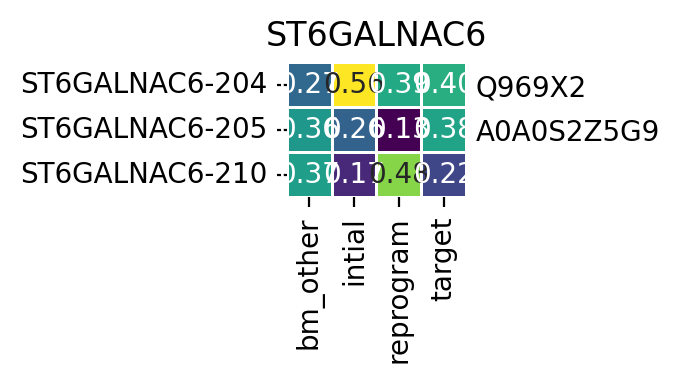

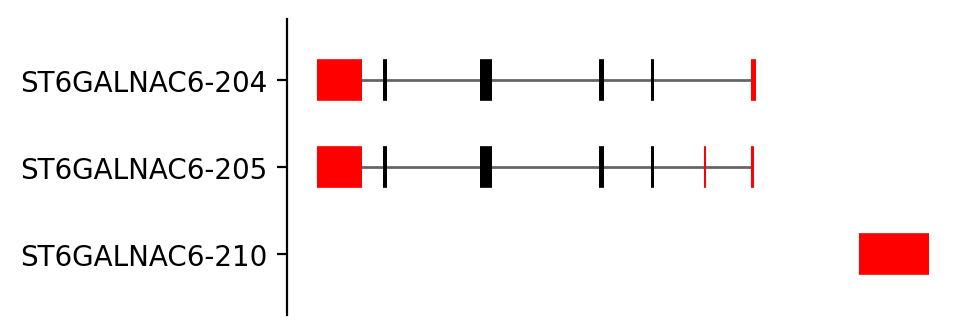

========== HSH2D ==========
tmp.shape=(5, 23)
transcript_name  total_transcript
      HSH2D-202            1918.0
      HSH2D-204              39.0
      HSH2D-206            2892.0
      HSH2D-207            1972.0
      HSH2D-208              92.0
(5, 4)


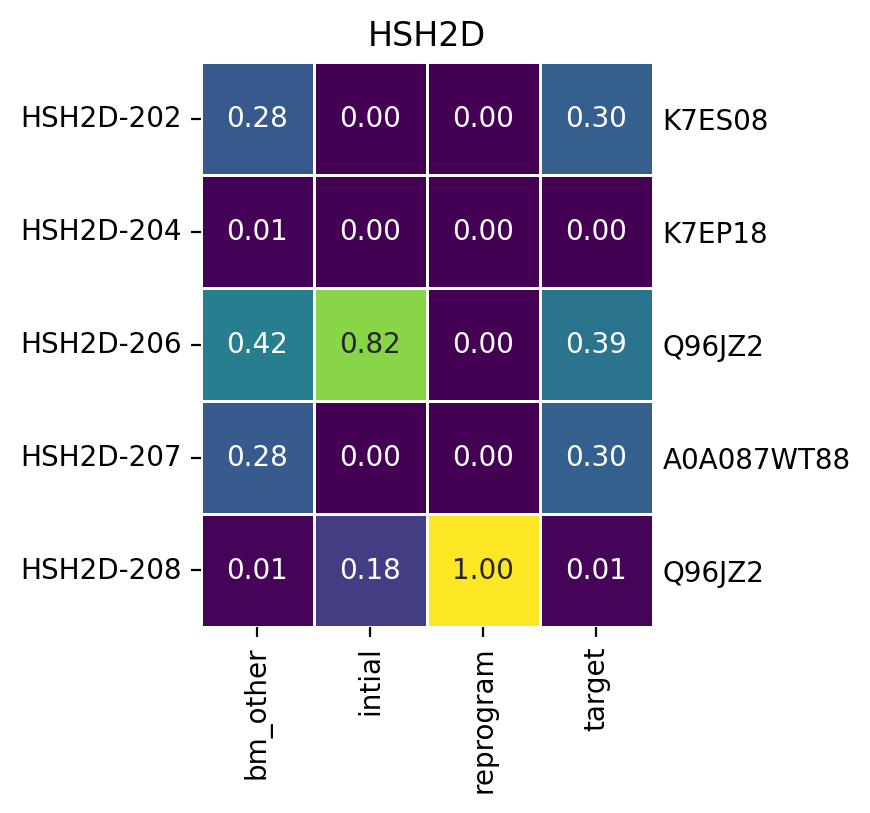

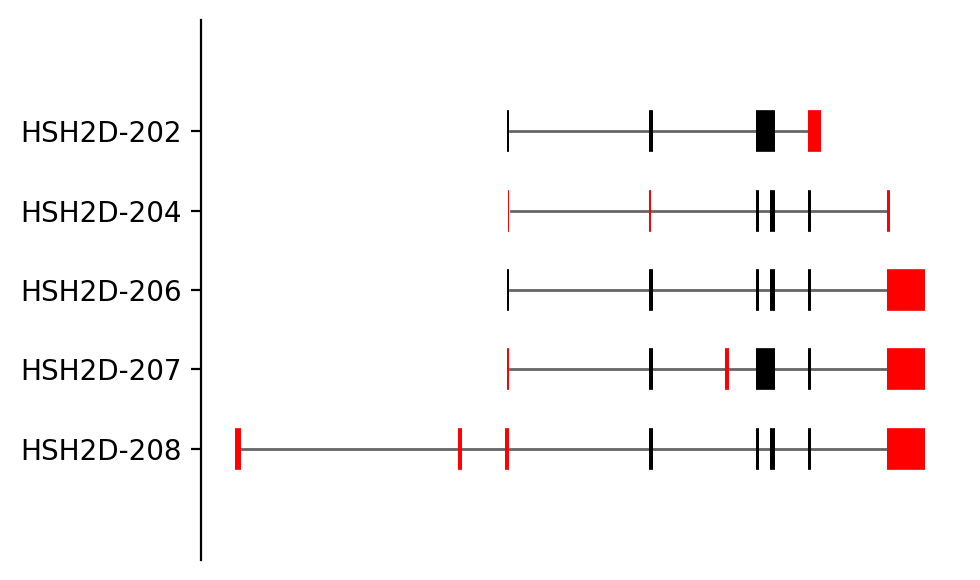

========== CPEB1 ==========
tmp.shape=(5, 23)
transcript_name  total_transcript
      CPEB1-201             170.0
      CPEB1-205             160.0
      CPEB1-209             103.0
      CPEB1-217              65.0
      CPEB1-218              32.0
(5, 4)


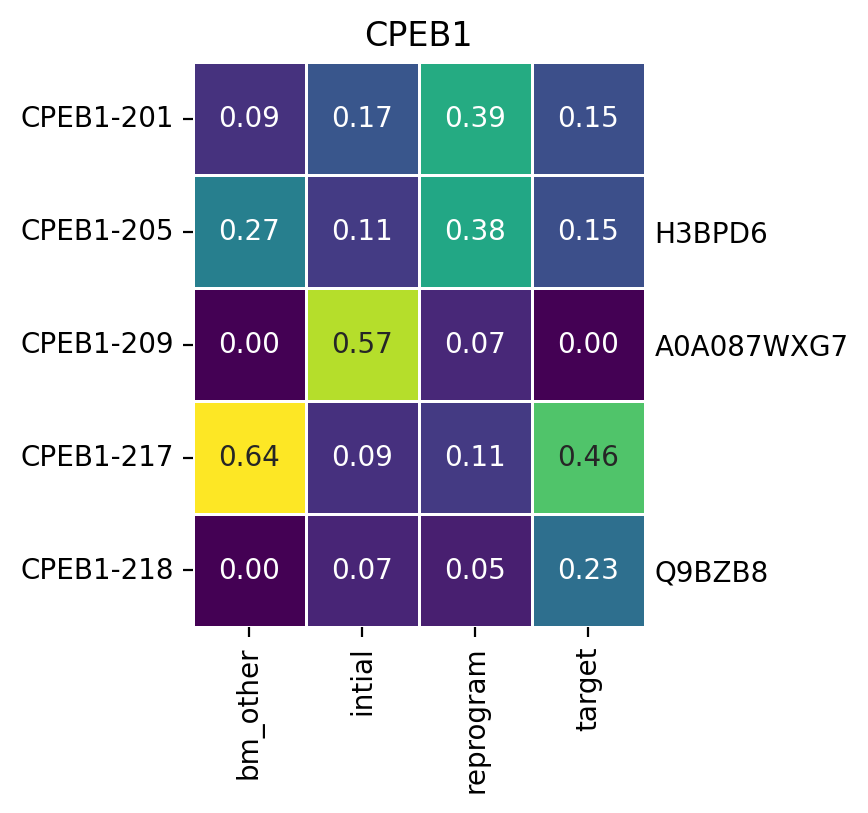

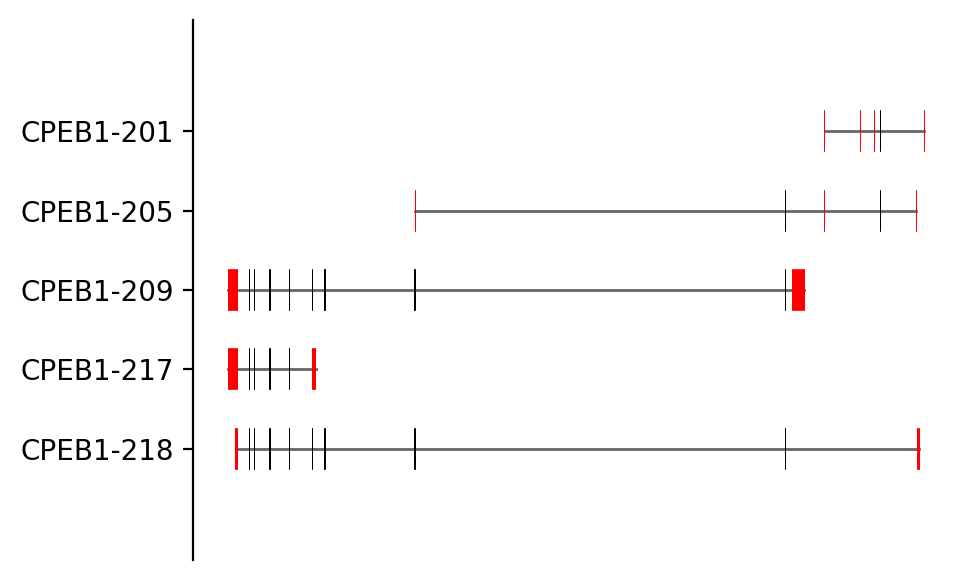

========== HR ==========
tmp.shape=(3, 23)
transcript_name  total_transcript
         HR-201              72.0
         HR-202              54.0
         HR-206              40.0
(3, 4)


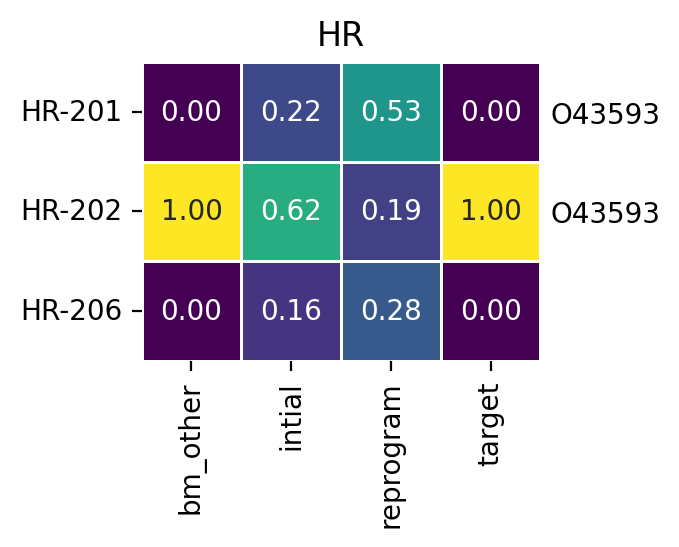

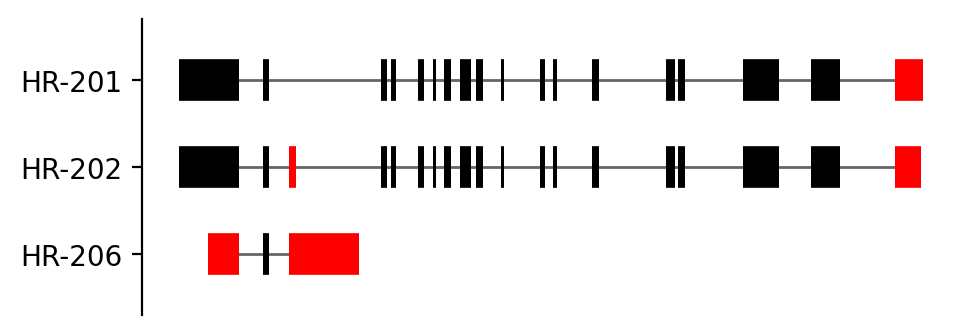

========== OSER1-DT ==========
tmp.shape=(8, 23)
transcript_name  total_transcript
   OSER1-DT-201              46.0
   OSER1-DT-203             167.0
   OSER1-DT-204              69.0
   OSER1-DT-206             193.0
   OSER1-DT-207             103.0
   OSER1-DT-210              53.0
   OSER1-DT-211             578.0
   OSER1-DT-212              37.0
(8, 4)


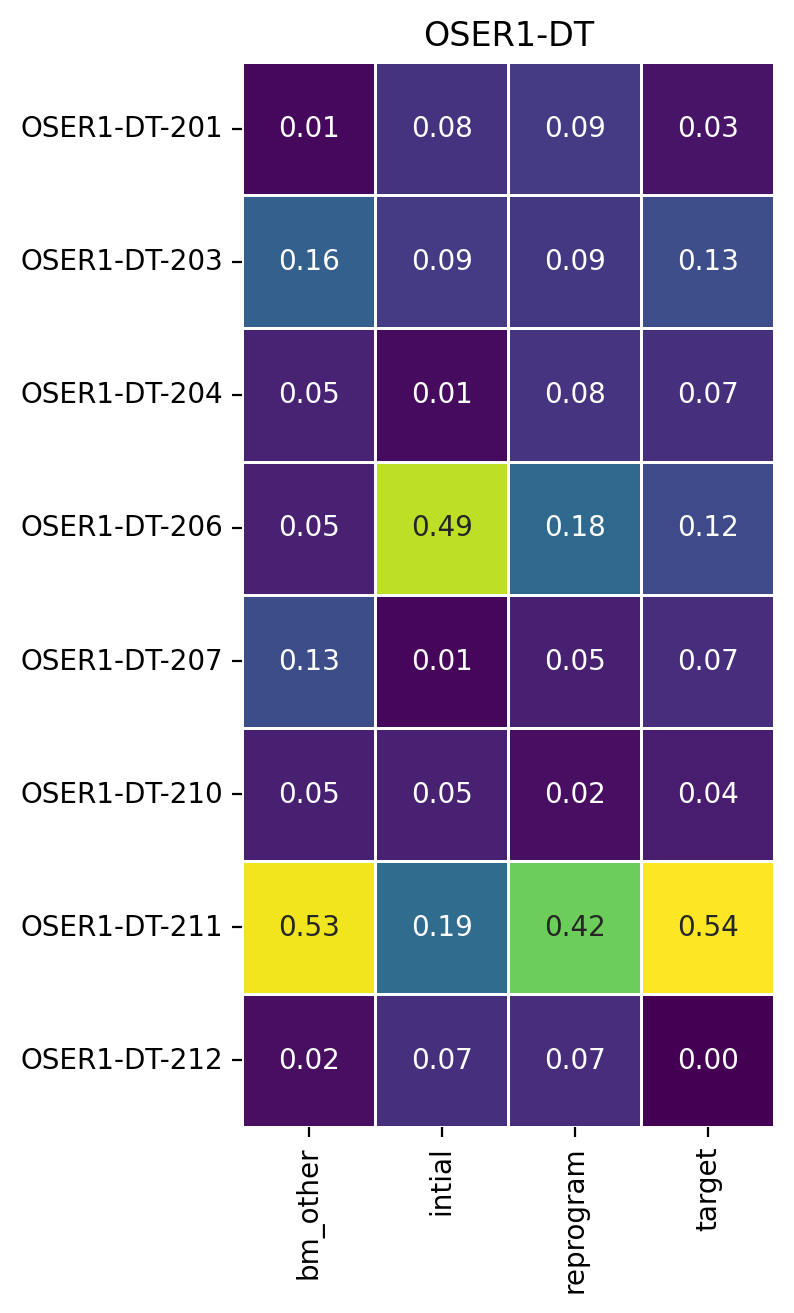

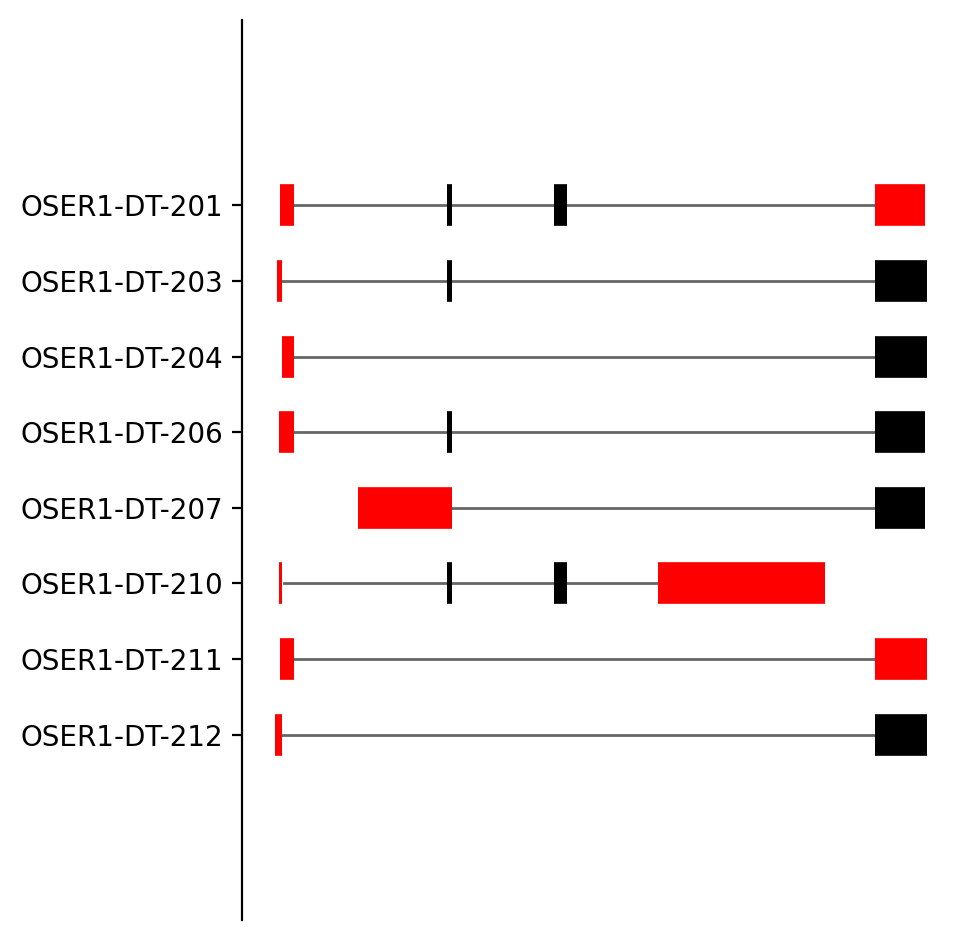

========== CTPS1 ==========
tmp.shape=(8, 23)
transcript_name  total_transcript
      CTPS1-208              65.0
      CTPS1-210              61.0
      CTPS1-211             395.0
      CTPS1-212             492.0
      CTPS1-216             128.0
      CTPS1-217             603.0
      CTPS1-218             109.0
      CTPS1-220             242.0
(8, 4)


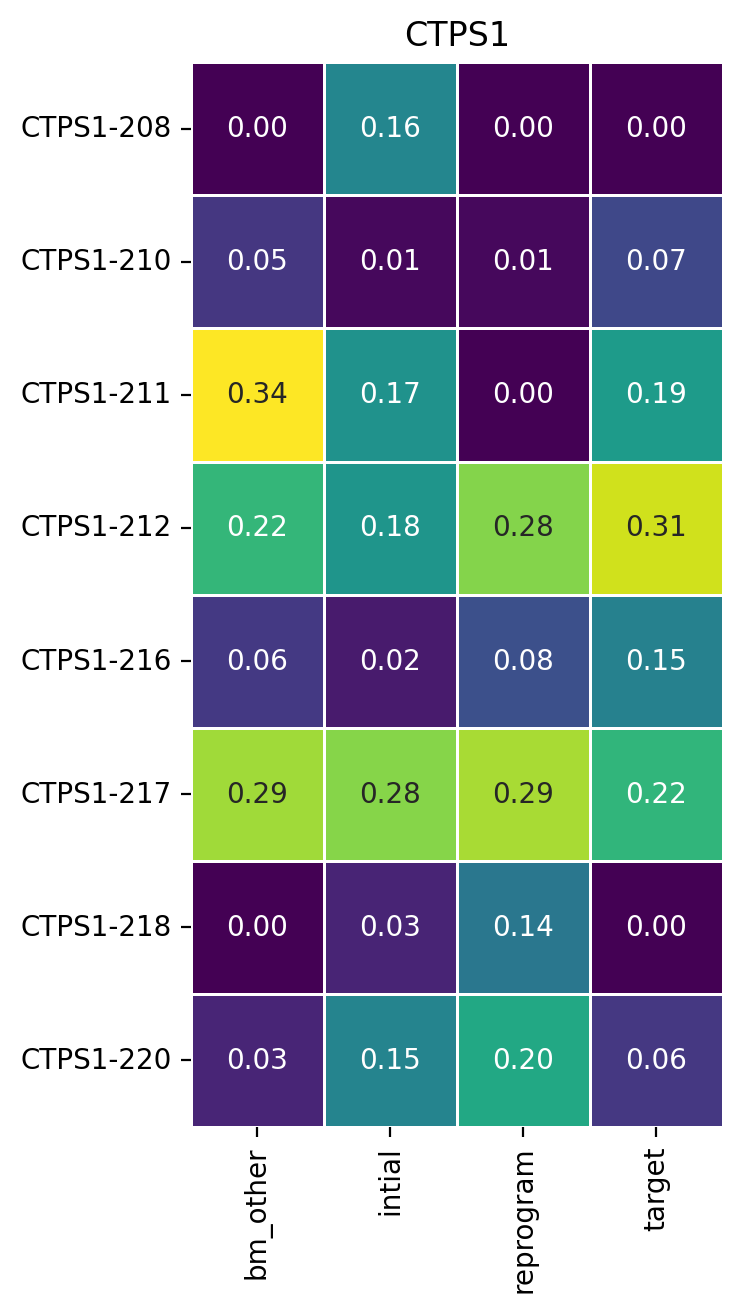

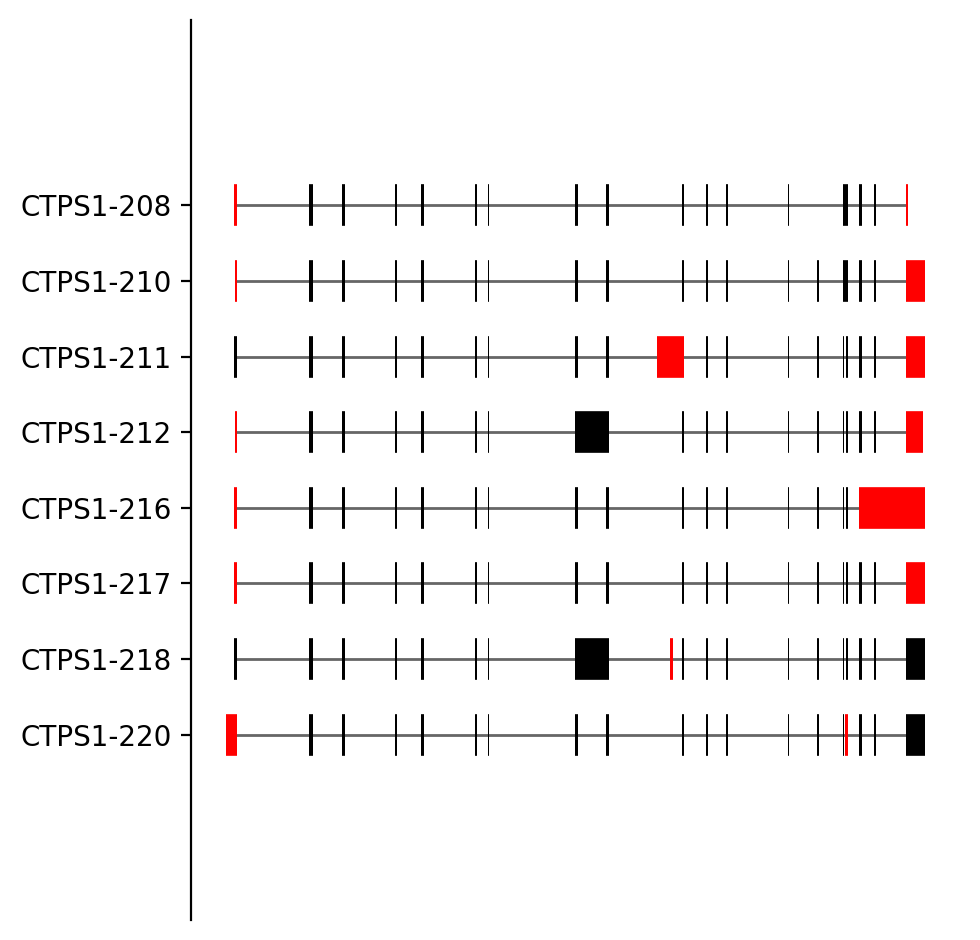

========== ENSG00000266977 ==========
tmp.shape=(2, 23)
transcript_name  total_transcript
ENST00000589471             230.0
ENST00000669145              73.0
(2, 4)


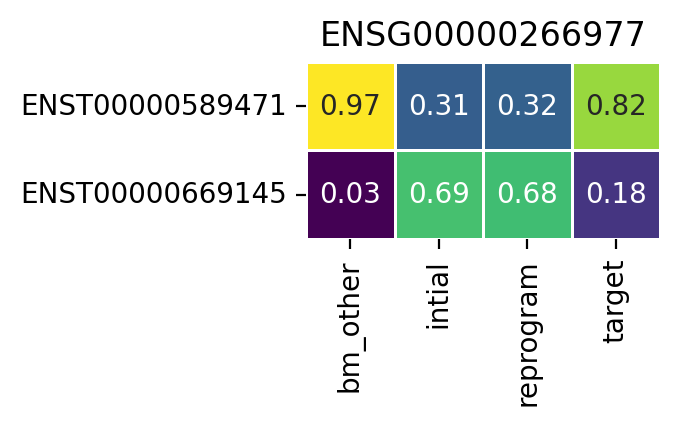

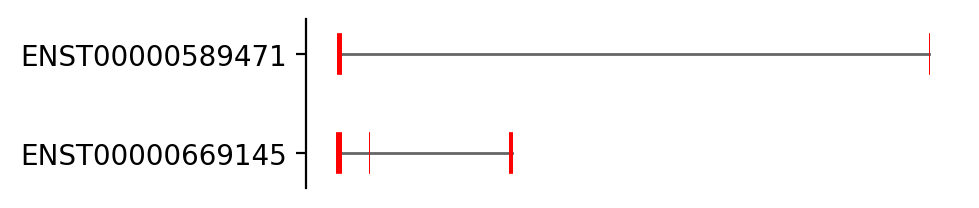

========== EPB41L4A-AS1 ==========
tmp.shape=(3, 23)
 transcript_name  total_transcript
EPB41L4A-AS1-205            2724.0
EPB41L4A-AS1-207             211.0
EPB41L4A-AS1-208             442.0
(3, 4)


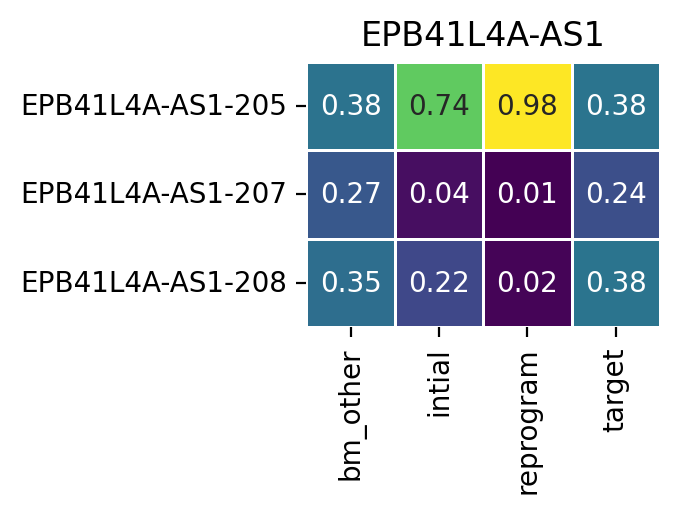

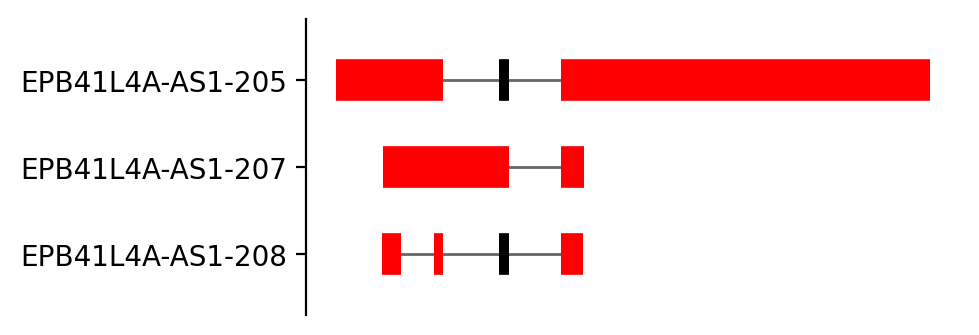

In [274]:
plot_df = pdf.copy()

# Drop rows where all _top values are the same (excluding NaN-only rows)
top_cols = ['intial_pct_top', 'reprogram_pct_top', 'target_pct_top']
mask = plot_df[top_cols].nunique(axis=1, dropna=False) == 1
plot_df = plot_df[~mask]

sample_size = 10
gene_list = pd.Series(plot_df['gene_name'].unique()).sample(sample_size).values

for gene in gene_list:
    print(f"{'=' * 10} {gene} {'=' * 10}")
    tmp = plot_df[plot_df['gene_name'] == gene]
    print(f"{tmp.shape=}")
    transcripts = tmp['transcript_name'].to_list()

    plot_gene_heatmap(gene, plot_df, transcript_2_uniprot)
    plot_transcript_models(exons, transcripts)

    # break
    

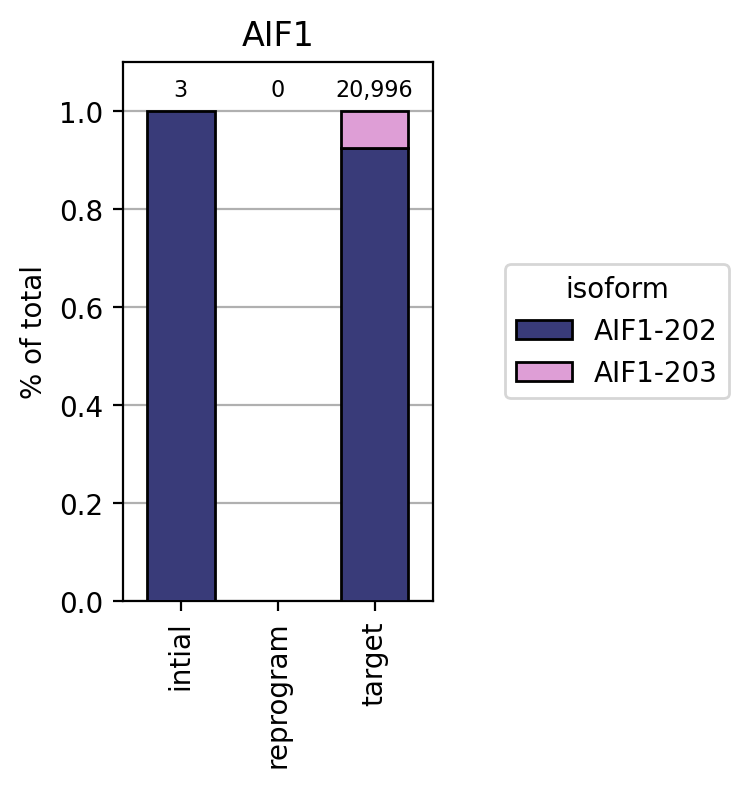

In [276]:
def plot_isoform_stack(pdf, gene_name, figsize=(2, 3.5), cmap='tab20b'):
    """
    Plot a stacked bar chart of isoform percentages by condition for a given gene.

    Parameters:
    - pdf: DataFrame containing columns: gene_name, transcript_name, *_sum, *_pct
    - gene_name: str, gene to plot
    - figsize: tuple, figure size
    - cmap: matplotlib colormap name
    """
    # Subset data
    df = pdf[pdf['gene_name'] == gene_name].copy()

    # Extract isoform fractions
    pct_df = df[['transcript_name', 'intial_pct', 'reprogram_pct', 'target_pct']].set_index('transcript_name')
    pct_df.columns = [col.replace("_pct", "") for col in pct_df.columns]
    pct_df = pct_df.T

    # Plot
    ax = pct_df.plot(
        kind='bar',
        stacked=True,
        figsize=figsize,
        width=0.7,
        edgecolor='black',
        zorder=10,
        cmap=cmap,
    )

    # Get sums from first row
    sums = df.iloc[0][['intial_sum', 'reprogram_sum', 'target_sum']]
    sums.index = [col.replace("_sum", "") for col in sums.index]

    # Annotate sums
    for i, (label, total) in enumerate(sums.items()):
        ax.text(i, 1.02, f"{int(total):,}", ha='center', va='bottom', fontsize=8)

    # Style
    plt.ylim(0, 1.1)
    plt.grid(axis='y')
    plt.ylabel("% of total")
    plt.xlabel("")
    plt.title(f"{gene_name}")
    plt.legend(
        title="isoform",
        bbox_to_anchor=(2.0, 0.5),
        loc='center right',
    )
    plt.tight_layout()
    plt.show()

plot_isoform_stack(pdf, "AIF1")

# Literature genes

In [ ]:
gene_list = [
    "IKZF1", "NFIB", "MDM4", "RUNX1", "HMGA2", "NUMB", "NOTCH", "LAS1L", "ATP5F1C", "HDAC7",
    "CPSF3", "HNRNP UL1", "TIA1", "PTBP1", "SRSF3", "RBFOX2", "SRSF2", "SRSF1", "RUNX1A", "CLK3",
    "SRSF2", "RUNX1", "GATA2", "ETV2", "TAL1",
    "HBA1", "HBB", "ALB", "TFRC", "GATA1", "CD34", "CD3D", "CD19", "VWF", "MPO", "PF4", "PRTN3",
    "KLF1", "MYB", "GFI1B", "SPI1", "PBX1", "MEIS1",
    "U1/U2/U4/U5/U6 SNRNPS", "SRSF1-7", "SF3B1", "PRPF8", "RBM PROTEINS", "HNRNPS"
]

for gene in gene_list:
    if gene in pdf['gene_name'].unique():
        plot_isoform_stack(pdf, gene)


In [ ]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

rsc.get.anndata_to_CPU(adata)

# query = 'CD34'
query = 'LAS1L'
tx_list = adata.var[adata.var['gene_name'] == query].index.to_list()
print(tx_list)

sc.pl.umap(
    adata,
    ncols=4,
    sort_order=True,
    color=tx_list,
    size=75,
    add_outline=True,
    outline_color=('k', 'k'),
    alpha=1,
    frameon=False,
)

In [ ]:
break

In [ ]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 3, 3

sns.scatterplot(
    data=pdf,
    x='intial_pct',
    y='target_pct',
    hue='reprogram_pct',
    palette='bwr',
    s=10,
    alpha=0.5,
    ec='none',
    legend=None,
)

In [ ]:
break

# Differential Isoform Expression

In [ ]:
%%time
rsc.get.anndata_to_CPU(adata)
sc.tl.rank_genes_groups(
    adata, 
    groupby='group',
    method='wilcoxon',
    use_raw=False,
    pts=True,
)

deg = sc.get.rank_genes_groups_df(
    adata, 
    group=None,
    pval_cutoff=0.05,
    log2fc_min=1.0,
    log2fc_max=10.0,
)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 6, 3
sc.pl.rank_genes_groups(
    adata,
    n_genes=35,
    sharey=False,
    ncols=3,
)

deg.head()